In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from joblib import dump, load

from xai_aux import CFCalculations

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
2025-01-23 11:49:55.780388: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-23 11:49:55.860234: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-23 11:49:56.121113: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-23 11:49:56.121162: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-23 11:49:56.163621: E external/local_xla/x

In [2]:
def get_distance(A,B, continuous_columns, categorical_columns, l_norm=2):
    
    combined = np.vstack((A, B))
    
    stds = np.std(combined[:, categorical_columns], axis=0)
    epsilon = 1e-8
    adjusted_stds = np.where(stds == 0, epsilon, stds) 

    weights_categorical = 1.48 / adjusted_stds
    mads = np.median(np.abs(combined[:, continuous_columns] - 
                            np.median(combined[:, continuous_columns], axis=0)), axis=0)
    adjusted_mads = np.where(mads == 0, epsilon, mads) 
    weights_continuous = 1 / adjusted_mads

    # Combine weights
    weights = np.zeros(combined.shape[1])
    weights[categorical_columns] = weights_categorical
    weights[continuous_columns] = weights_continuous

    # Compute weighted L2 distances for same-index pairs
    differences = A - B  # Element-wise differences
    weighted_differences = differences * weights  # Apply weights element-wise
    l_distances = np.linalg.norm(weighted_differences, axis=1, ord=l_norm)
    return l_distances

In [3]:
mock_data = "3"
cf_results_dict = load("cf_results_dict_mock_data"+mock_data+".pkl")
cf_calc = load("cf_calc_mock_data"+mock_data+".pkl")
model_results_dict = load("model_results_dict"+mock_data+".pkl")
cfs_good_indices = load("cfs_good_indices"+mock_data+".pkl")

In [4]:
n_features = cf_results_dict['noise_0'][('lr','dice')].shape[1]

IndexError: list index out of range

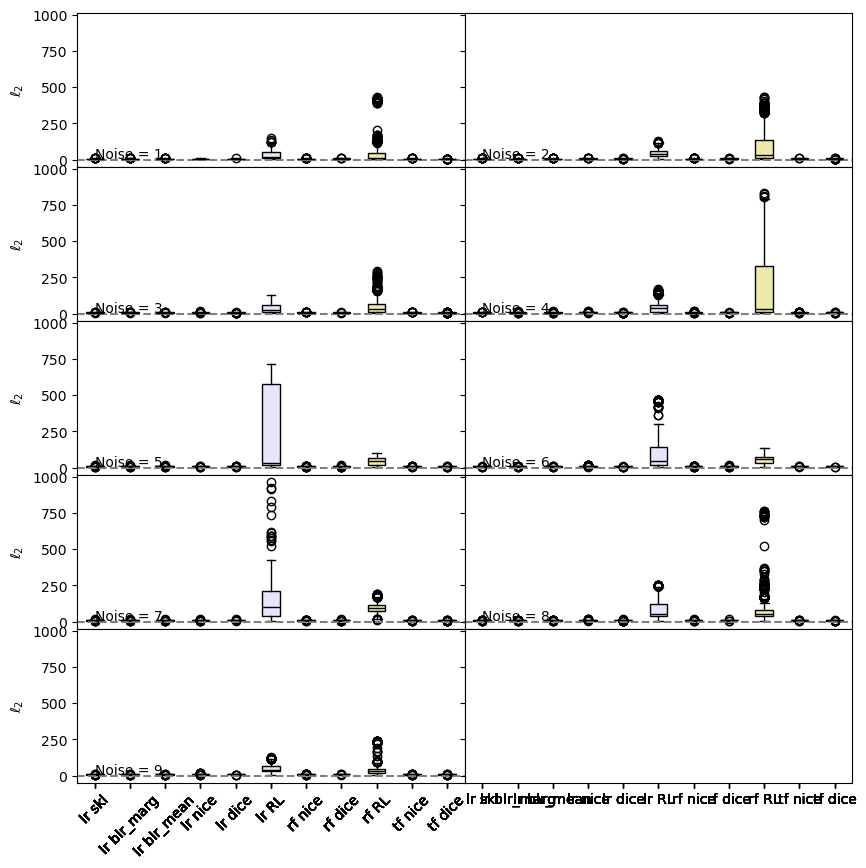

In [6]:
# TODO use only good CFs e.g. cfs_good_indices['noise_10'][('lr','blr_marg')]
numerical_columns = [int(i) for i in cf_calc.num_cols_tf]
categorical_columns = [int(i) for i in cf_calc.cat_cols_tf]
cm = ['TP','FP','FN','TN']
noises_list = list(cf_results_dict.keys())[1:]
colors = ['deepskyblue', 'lightblue','blue', 'magenta','hotpink', 'lavender', 'darkorange','orange', 'palegoldenrod', 'darkgreen','lightgreen']
#colors = ['deepskyblue', 'lightblue','blue', 'magenta','hotpink', 'darkorange','orange', 'darkgreen','lightgreen']
fig, axes = plt.subplots(5, 2, figsize=(10, 10), sharex=True, sharey=True)
axes = axes.flatten()
l_order = 2
for i, ax in enumerate(axes):
    d2 = []
    labels = []
    for k in cf_results_dict['noise_0'].keys():
        if k[1]=='RL': continue
        A = cf_results_dict[noises_list[i]][k]
        B = cf_results_dict['noise_0'][k]
        if k[1]=='nice' or k[1]=='dice' or k[1]=='RL':
            if k[0]!='tf':
                A = cf_calc.models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
                B = cf_calc.models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)
        good_indices = cfs_good_indices[noises_list[i]][k]
        d2.append(get_distance(A[good_indices], B[good_indices], numerical_columns, categorical_columns, l_norm=l_order))
        #d2.append(get_distance(A, B, numerical_columns, categorical_columns, l_norm=l_order))
        labels.append(k[0]+' ' + k[1])
    bplot = ax.boxplot(d2, tick_labels=labels, widths=0.5, patch_artist=True)
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
    for median in bplot['medians']:
        median.set_color('black')
    #ax.set_ylim(y_lim)
    fig.subplots_adjust(wspace=0, hspace=0)  # Set space between subplots to zero
    ax.tick_params(axis='x', labelrotation=45)
    ax.text(1,12,'Noise = ' + noises_list[i][6:9])
    # if i==0:
    #     ax.text(1,45,cm_in)
    ax.axhline(y=0,linestyle='--',color='grey')
    if np.mod(i,2)==0:
        ax.set_ylabel(r'$\ell_2$')

In [ ]:
#kk = list(cf_results_dict['noise_0'].keys())[0]
colors = ['deepskyblue', 'lightblue','blue', 'magenta','hotpink', 'lavender', 'darkorange','orange', 'palegoldenrod', 'darkgreen','lightgreen']
for i, kk in enumerate(cf_results_dict['noise_0'].keys()):
    #if kk[1]=='blr_marg' or kk[1]=='RL': continue
    x_acc = []
    d2 = []
    for k in cf_results_dict:
        if k=='noise_0': continue
        x_acc.append(model_results_dict[k][(kk[0],'accuracy')])
        A = cf_results_dict[k][kk]
        B = cf_results_dict['noise_0'][kk]
        if kk[1]=='nice' or kk[1]=='dice':
            if kk[0]!='tf':
                A = cf_calc.models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
                B = cf_calc.models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)
        #good_indices = cfs_good_indices[k][kk] # we ignore that because it won't work for plotting. This is a >5% level effect.
        d2.append(get_distance(A, B, numerical_columns, categorical_columns, l_norm=2))
        
    d2 = np.array(d2)
    plt.plot(x_acc, d2.mean(axis=1), color=colors[i],label=kk[0]+' '+kk[1],alpha=1, linestyle='--', marker='o')
    plt.fill_between(x_acc, np.percentile(d2,40,axis=1), np.percentile(d2,60,axis=1), color=colors[i],alpha=0.2)
plt.legend(frameon=False)
plt.ylabel(r'$\ell_2$')
plt.xlabel('Model Accuracy')
plt.gca().invert_xaxis()
if mock_data=="1":
    plt.ylim([0, 5])